# Sign Language
Data Analysis - ISAE 2025/2026

In [21]:
import os
import sys

REPO_URL = "https://github.com/PetitMalo/BE_data_analysis.git"
REPO_NAME = "BE_data_analysis"
SEED = 42

if "google.colab" in str(get_ipython()):
    if not os.path.exists(REPO_NAME):
        !git clone {REPO_URL}

    os.chdir(REPO_NAME)

    !curl -LsSf https://astral.sh/uv/install.sh | sh
    os.environ["PATH"] += ":" + os.path.expanduser("~/.cargo/bin")

    print("Installation des dépendances via uv...")
    !uv pip install --system -r pyproject.toml

    repo_path = os.getcwd()
    if repo_path not in sys.path:
        sys.path.append(repo_path)

In [ ]:
import json
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import skimage
import xgboost as xgb
from scipy import ndimage
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

from src.hyper_param_search import find_xgb_hyperparams_gpu, find_mlp_hyperparams
from src.utils import logger

%matplotlib inline

Loading the dataset

In [23]:
data_path = "./data"
X_file = os.path.join(data_path, "X.npy")  # X
y_file = os.path.join(data_path, "y.npy")  # y

## 1 - Data import and formatting


In [24]:
# Load input data and labels
X = np.load(X_file)
y = np.load(y_file)
print("Shapes of input data:")
print(X.shape)
print("Shapes of labels:")
print(y.shape)

Shapes of input data:
(2062, 64, 64)
Shapes of labels:
(2062, 10)


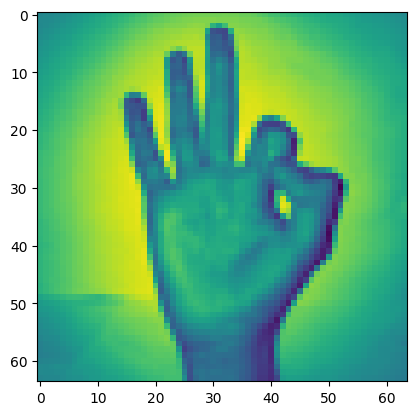

Label of image is:
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [25]:
# Display an image and its label
img_idx = 55
plt.imshow(X[img_idx])
plt.show()
print("Label of image is:")
print(y[img_idx])

In [26]:
# Let's define a function that converts the one-hot encoded labels to the corresponding sign
# language value.
def label_to_sign_number(label: int) -> int:
    """
    Convert a one-hot encoded label to the
    corresponding sign language value.
    Mapping it with the truth value.

    Args:
      label: (numpy.array) One-hot encoded label

    Returns: (float) Sign language value
    """
    label_value = np.argmax(label)
    mapping = {0: 9, 1: 0, 2: 7, 3: 6, 4: 1, 5: 8, 6: 4, 7: 3, 8: 2, 9: 5}
    return mapping[label_value]

Image 55 is a: 9


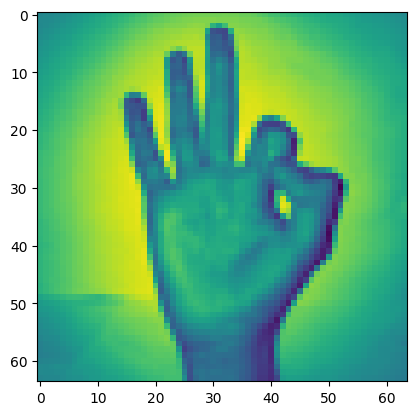

In [27]:
# Let's test our function
y55 = label_to_sign_number(y[img_idx])
print("Image 55 is a: {}".format(y55))
plt.imshow(X[img_idx])
plt.show()

## 2 - Features construction with filters

In [28]:
# Let's apply some edge detectors on an example image
img_idx = 900  # select an image index
img = X[img_idx]  # get the grayscale image matrix

# Sobel operator
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
gx = ndimage.convolve(img, sobel_x)
gy = ndimage.convolve(img, sobel_y)
edges_sobel = np.sqrt(gx**2 + gy**2)

# Laplacian operator
laplacian = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
edges_laplacien = ndimage.convolve(img, laplacian)

# Personal operator (sobel + max pooling 2D)
processed_img = ndimage.convolve(img, sobel_x)
processed_img = skimage.measure.block_reduce(processed_img, (2, 2), np.max)

# processed_img2 = ndimage.convolve(img, sobel_x)
# processed_img2 = skimage.measure.block_reduce(processed_img2, (2, 2), np.max)

other_processed_img = ndimage.convolve(img, laplacian)
other_processed_img = skimage.measure.block_reduce(other_processed_img, (2, 2), np.max)

# other_processed_img2 = ndimage.convolve(img, laplacian)
# other_processed_img2 = skimage.measure.block_reduce(other_processed_img2, (2, 2), np.max)

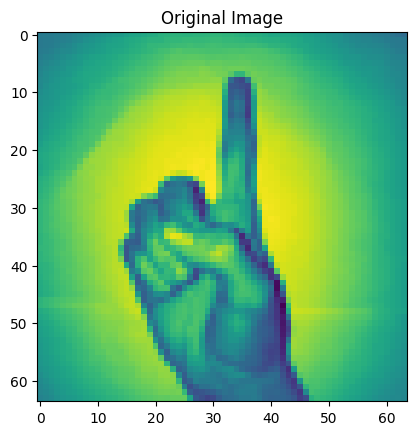

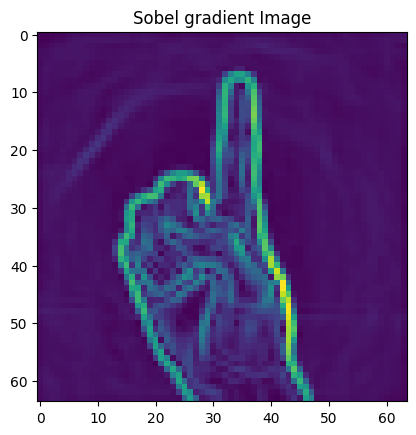

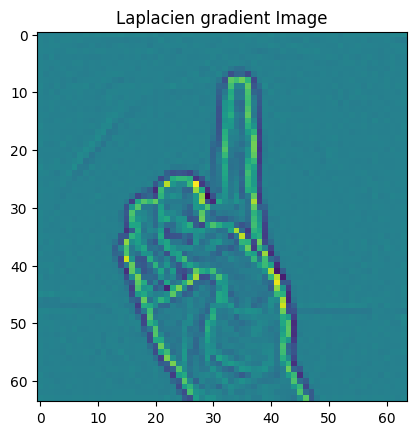

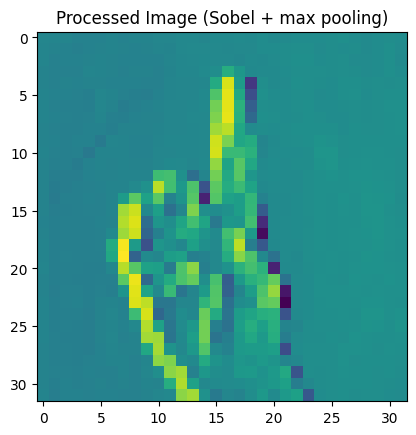

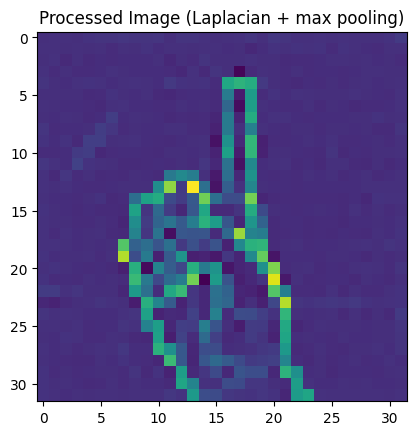

In [29]:
# Let's display the image
def displayImg(_img, title=""):
    plt.imshow(_img)
    plt.title(title)
    plt.show()


displayImg(img, "Original Image")
displayImg(edges_sobel, "Sobel gradient Image")
displayImg(edges_laplacien, "Laplacien gradient Image")
displayImg(processed_img, "Processed Image (Sobel + max pooling)")
displayImg(other_processed_img, "Processed Image (Laplacian + max pooling)")
# displayImg(processed_img2, "Processed Image (max pooling + sobel)")
# displayImg(other_processed_img2, "Processed Image (max pooling + laplacian)")

# print((other_processed_img2 - other_processed_img == 0).all())

In [ ]:
def preprocessing(
    X: np.ndarray, y: np.ndarray, scaler_dir: str = "./models/scaler"
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Preprocess the input data by applying sobel filter and maxpooling.

    Args:
        X: (numpy.array) Input data of shape (num_samples, height, width)
        y: (numpy.array) Labels of shape (num_samples, num_classes)
        scaler_dir: (str) Directory to save the scaler parameters
    Returns:
        X_train, X_val, X_test, y_train, y_val, y_test: (tuple) Preprocessed data and labels
    """
    logger.info("Preprocessing dataset")
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    X_processed = []
    for img in tqdm(X, desc="Preprocessing images", total=len(X)):
        gx = ndimage.convolve(img, sobel_x)
        gy = ndimage.convolve(img, sobel_y)
        edges_sobel = np.sqrt(gx**2 + gy**2)
        processed_img = skimage.measure.block_reduce(edges_sobel, (2, 2), np.max)
        X_processed.append(processed_img)

    # Train, test, split
    logger.info("Splitting dataset into train, validation and test sets")
    X_processed = np.array(X_processed)
    X_flat = X_processed.reshape((X_processed.shape[0], -1))  # flatten the images
    y_flat = np.array([label_to_sign_number(label) for label in y])
    X_train, X_test, y_train, y_test = train_test_split(
        X_flat, y_flat, test_size=0.25, random_state=SEED, stratify=y_flat
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.25, random_state=SEED, stratify=y_train
    )

    logger.info("Scaling dataset")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    X_val = scaler.transform(X_val)

    os.makedirs(scaler_dir, exist_ok=True)
    logger.info(f"Saving scaler to: {scaler_dir}")
    with open(
        os.path.join(scaler_dir, f"scaler_params_{datetime.now().strftime('%Y%m%dT%H%M%S')}.json"),
        "w",
    ) as f:
        json.dump(
            {
                "mean": scaler.mean_.tolist(),
                "scale": scaler.scale_.tolist(),
            },
            f,
        )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [31]:
X_train, X_val, X_test, y_train, y_val, y_test = preprocessing(X, y)

2026-02-09 10:20:31.305 | INFO     | __main__:preprocessing:14 - Preprocessing dataset
Preprocessing images: 100%|██████████| 2062/2062 [00:00<00:00, 3248.70it/s]
2026-02-09 10:20:31.954 | INFO     | __main__:preprocessing:26 - Splitting dataset into train, validation and test sets
2026-02-09 10:20:31.967 | INFO     | __main__:preprocessing:37 - Scaling dataset
2026-02-09 10:20:31.980 | INFO     | __main__:preprocessing:44 - Saving scaler to: ./models/scaler


## 3 - Classification with models

### 3.1 - Ensembling models

#### 3.1.1 - XGBClassifier

In [ ]:
search_xgb_best_params = False
if search_xgb_best_params:
    logger.info("Searching for optimal hyperparameters...")
    hyper_params = find_xgb_hyperparams_gpu(X_train, y_train, X_val, y_val)
    logger.info(f"Optimal hyperparameters found: {hyper_params}")

In [33]:
try:
    logger.info("Best hyperparameters:")
    logger.info(hyper_params)
except NameError:
    best_hyperparam_path = "./models/xgb_best_hyperparams.json"
    with open(best_hyperparam_path, "r") as f:
        hyper_params = json.load(f)
    logger.info(f"Using previously found hyperparameters from: {best_hyperparam_path}")
    logger.info(hyper_params)

clf = xgb.XGBClassifier(**hyper_params, random_state=SEED).fit(X_train, y_train)
score = clf.score(X_test, y_test)
logger.info(f"Test set accuracy: {score}")

2026-02-09 10:20:32.004 | INFO     | __main__:<module>:2 - Best hyperparameters:
2026-02-09 10:20:32.007 | INFO     | __main__:<module>:3 - {'n_estimators': 172, 'max_depth': 6, 'learning_rate': 0.03747310270498051, 'subsample': 0.6872456904693164}
2026-02-09 10:22:32.789 | INFO     | __main__:<module>:13 - Test set accuracy: 0.7906976744186046


### 3.2 - MLPClassifier

In [ ]:
search_mlp_best_params = True
if search_mlp_best_params:
    logger.info("Searching for optimal hyperparameters...")
    hyper_params = find_mlp_hyperparams_gpu(X_train, y_train, X_val, y_val)
    logger.info(f"Optimal hyperparameters found: {hyper_params}")

In [35]:
mlp_clf = MLPClassifier(random_state=SEED).fit(X_train, y_train)
score = mlp_clf.score(X_test, y_test)
logger.info(f"Test set accuracy: {score}")

2026-02-09 10:22:41.456 | INFO     | __main__:<module>:3 - Test set accuracy: 0.7655038759689923
